# 04. Compare high-quality vs low-quality ticker universes

Sanity check on the 02 filter: did dropping the 24 low-quality tickers actually improve the weekly CC/CSP strategy, or just shrink the universe?

**LQ universe** (24 tickers, `FILTERED_TICKERS - HIGH_QUALITY_TICKERS`):

```
['ALKT', 'ARQQ', 'BE', 'BYND', 'BYRN', 'CAI', 'CEG', 'CLOV', 'DDD', 'DNUT', 'KOPN', 'KULR', 'LAC', 'LAES', 'LTBR', 'NFE', 'NNE', 'NVTS', 'QSI', 'RR', 'SERV', 'SLI', 'UMAC', 'ZETA']
```

**Comparison metrics:**

- `n_rows` — how many clean decision points each universe generates; LQ should have far fewer (monthly-only tickers contribute ~0).
- `pct_OTM_at_exp` — success rate; depends on underlying price motion, should be comparable between HQ and LQ.
- `median_spread_rel` — HQ should be lower by design.
- `mean_pnl_bid_pct` — conservative P&L with spread cost; HQ should be higher (filter's main economic claim).
- `mean_pnl_mark_pct` — idealized P&L at mark fill; if HQ and LQ look similar here, the filter is doing its job on execution rather than "picking tickers with fundamentally better CC/CSP edge".
- `sharpe_annual` — volatility-adjusted, annualized from weekly; the real question for a portfolio.


In [1]:
import math
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from config import FILTERED_TICKERS, HIGH_QUALITY_TICKERS


LQ_TICKERS = sorted(set(FILTERED_TICKERS) - set(HIGH_QUALITY_TICKERS))
TYPES = ["CC", "CSP"]
YIELD_TARGETS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030, 0.035, 0.040, 0.045, 0.050]
EXPECTED_DTE = 4
MIN_BID = 0.05
MIN_OI = 10
YIELD_MATCH_TOLERANCE = 0.25

WINDOW_START = pd.Timestamp("2020-01-01")
WINDOW_END = pd.Timestamp("2026-04-02")

HQ_PARQUET = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
LQ_PARQUET = Path("output/04_compare_high_vs_low_quality_ticker/strategy_labels_lq.parquet")
LQ_CSV = Path("output/04_compare_high_vs_low_quality_ticker/strategy_labels_lq.csv")

DATE_RE = re.compile(r"_(\d{4}-\d{2}-\d{2})\.csv$")
OPTIONS_COLS = [
    "contractID",
    "expiration",
    "strike",
    "type",
    "bid",
    "ask",
    "mark",
    "volume",
    "open_interest",
    "delta",
    "implied_volatility",
]

## Build LQ labels

Same label-building logic as notebook 03, just run against the 24 LQ tickers. Written to `data/strategy_labels_lq.parquet` (and a CSV peek copy).


In [2]:
def load_trading_days():
    df = pd.read_csv("data/daily_alpha/AAPL.csv", usecols=["date"])
    return set(pd.to_datetime(df["date"]).dt.date)


def load_daily_close(ticker):
    p = Path("data/daily_alpha") / f"{ticker}.csv"
    if not p.exists():
        return {}
    df = pd.read_csv(p, usecols=["date", "close"])
    df["date"] = pd.to_datetime(df["date"]).dt.date
    return dict(zip(df["date"], df["close"].astype(float)))


def build_labels(universe):
    trading_days = load_trading_days()
    drops = {
        "no_monday_file": 0,
        "monday_holiday": 0,
        "friday_holiday": 0,
        "no_friday_close": 0,
        "no_exact_friday_expiry": 0,
        "no_otm_of_type": 0,
        "bid_or_oi_filter": 0,
        "yield_out_of_reach": 0,
    }
    rows = []

    for ticker_i, ticker in enumerate(universe):
        tdir = Path("data/options_alpha") / ticker
        if not tdir.is_dir():
            continue
        daily_close = load_daily_close(ticker)
        mondays = []
        for f in tdir.iterdir():
            m = DATE_RE.search(f.name)
            if not m:
                continue
            snap = pd.Timestamp(m.group(1))
            if snap.weekday() != 0 or not (WINDOW_START <= snap <= WINDOW_END):
                continue
            mondays.append((snap, f))
        mondays.sort()

        for snap, snap_file in mondays:
            if snap.date() not in trading_days:
                drops["monday_holiday"] += 1
                continue
            friday = snap + pd.Timedelta(days=EXPECTED_DTE)
            if friday.date() not in trading_days:
                drops["friday_holiday"] += 1
                continue
            if friday.date() not in daily_close:
                drops["no_friday_close"] += 1
                continue
            spot = daily_close.get(snap.date())
            if spot is None:
                drops["no_monday_file"] += 1
                continue
            friday_close = daily_close[friday.date()]

            chain = pd.read_csv(snap_file, usecols=OPTIONS_COLS)
            chain["expiration"] = pd.to_datetime(chain["expiration"])
            for numcol in (
                "bid",
                "ask",
                "mark",
                "delta",
                "implied_volatility",
                "open_interest",
                "strike",
            ):
                chain[numcol] = pd.to_numeric(chain[numcol], errors="coerce")
            chain = chain.dropna(subset=["delta", "mark", "bid", "ask", "strike"])

            friday_chain = chain[chain["expiration"].dt.date == friday.date()]
            if friday_chain.empty:
                drops["no_exact_friday_expiry"] += 1
                continue

            for type_key, opt_type, direction in [
                ("CC", "call", 1),
                ("CSP", "put", -1),
            ]:
                typed = friday_chain[friday_chain["type"] == opt_type]
                typed = (
                    typed[typed["strike"] > spot]
                    if direction == 1
                    else typed[typed["strike"] < spot]
                )
                if typed.empty:
                    drops["no_otm_of_type"] += 1
                    continue

                typed = typed[
                    (typed["bid"] >= MIN_BID) & (typed["open_interest"] >= MIN_OI)
                ]
                if typed.empty:
                    drops["bid_or_oi_filter"] += 1
                    continue

                if type_key == "CC":
                    typed = typed.assign(yield_actual=typed["mark"] / spot)
                else:
                    typed = typed.assign(yield_actual=typed["mark"] / typed["strike"])

                for yt in YIELD_TARGETS:
                    diffs = (typed["yield_actual"] - yt).abs()
                    best_idx = diffs.idxmin()
                    best = typed.loc[best_idx]
                    if abs(best["yield_actual"] - yt) / yt > YIELD_MATCH_TOLERANCE:
                        drops["yield_out_of_reach"] += 1
                        continue

                    strike = float(best["strike"])
                    mark = float(best["mark"])
                    bid = float(best["bid"])
                    ask = float(best["ask"])
                    delta = float(best["delta"])
                    iv = float(best["implied_volatility"])

                    if type_key == "CC":
                        moneyness_actual = strike / spot - 1.0
                        capital = spot * 100.0
                        assigned = friday_close > strike
                        intrinsic = max(0.0, friday_close - strike)
                    else:
                        moneyness_actual = 1.0 - strike / spot
                        capital = strike * 100.0
                        assigned = friday_close < strike
                        intrinsic = max(0.0, strike - friday_close)

                    prem_mark = mark * 100.0
                    prem_bid = bid * 100.0
                    assignment_pnl = -intrinsic * 100.0 if assigned else 0.0
                    net_pnl_mark = prem_mark + assignment_pnl
                    net_pnl_bid = prem_bid + assignment_pnl

                    rows.append(
                        {
                            "ticker": ticker,
                            "monday_date": snap.date(),
                            "friday_date": friday.date(),
                            "dte": EXPECTED_DTE,
                            "type": type_key,
                            "yield_target": yt,
                            "monday_close": spot,
                            "contract_id": best["contractID"],
                            "strike": strike,
                            "moneyness_actual": moneyness_actual,
                            "premium_mark": mark,
                            "bid": bid,
                            "ask": ask,
                            "spread_rel": (ask - bid) / mark if mark > 0 else None,
                            "delta": delta,
                            "iv": iv,
                            "yield_actual": float(best["yield_actual"]),
                            "friday_close": friday_close,
                            "return_pct": (friday_close / spot) - 1.0,
                            "assigned": bool(assigned),
                            "intrinsic_at_expiry": intrinsic,
                            "premium_received_mark": prem_mark,
                            "premium_received_bid": prem_bid,
                            "assignment_pnl": assignment_pnl,
                            "net_pnl_mark": net_pnl_mark,
                            "net_pnl_bid": net_pnl_bid,
                            "capital_per_contract": capital,
                            "pnl_pct_capital": net_pnl_bid / capital,
                            "p_mkt_success": 1.0 - abs(delta),
                        }
                    )

        print(
            f"  [{ticker_i + 1:2d}/{len(universe)}] {ticker:6s}  cumulative rows: {len(rows):,}"
        )

    df = pd.DataFrame(rows)
    if len(df):
        df["monday_date"] = pd.to_datetime(df["monday_date"])
        df["friday_date"] = pd.to_datetime(df["friday_date"])
    return df, drops


t0 = time.time()
print(f"Building LQ labels for {len(LQ_TICKERS)} tickers...")
lq_labels, lq_drops = build_labels(LQ_TICKERS)
elapsed = time.time() - t0

print(f"\nBuilt {len(lq_labels):,} LQ rows in {elapsed:.1f}s")

lq_labels.to_parquet(LQ_PARQUET, index=False)
lq_labels.to_csv(LQ_CSV, index=False)
print("Saved LQ labels:")
print(f"  parquet: {LQ_PARQUET} ({LQ_PARQUET.stat().st_size / 1024:,.1f} KB)")
print(f"  csv:     {LQ_CSV} ({LQ_CSV.stat().st_size / 1024:,.1f} KB)")

print("\nDrop counter:")
for k, v in lq_drops.items():
    print(f"  {k:26s}: {v:>8,}")

Building LQ labels for 24 tickers...


  [ 1/24] ALKT    cumulative rows: 37


  [ 2/24] ARQQ    cumulative rows: 326


  [ 3/24] BE      cumulative rows: 1,897


  [ 4/24] BYND    cumulative rows: 4,878


...

  [21/24] SERV    cumulative rows: 12,061


  [22/24] SLI     cumulative rows: 12,094


  [23/24] UMAC    cumulative rows: 12,557


  [24/24] ZETA    cumulative rows: 13,279

Built 13,279 LQ rows in 33.6s


Saved LQ labels:
  parquet: output\04_compare_high_vs_low_quality_ticker\strategy_labels_lq.parquet (751.2 KB)
  csv:     output\04_compare_high_vs_low_quality_ticker\strategy_labels_lq.csv (3,546.5 KB)

Drop counter:
  no_monday_file            :        0
  monday_holiday            :        0
  friday_holiday            :      166
  no_friday_close           :      144
  no_exact_friday_expiry    :    2,086
  no_otm_of_type            :       89
  bid_or_oi_filter          :    1,459
  yield_out_of_reach        :   14,061


## Union HQ + LQ with tier tag

Load both parquets, add a `tier` column, concatenate. Also add `pnl_pct_capital_mark` (mark-fill analog of the existing bid-fill column) to separate spread-cost effects from underlying-return effects.


In [3]:
hq = pd.read_parquet(HQ_PARQUET).assign(tier="HQ")
lq = pd.read_parquet(LQ_PARQUET).assign(tier="LQ")
both = pd.concat([hq, lq], ignore_index=True)
both["pnl_pct_capital_mark"] = both["net_pnl_mark"] / both["capital_per_contract"]
print(f"union: {len(both):,} rows  (HQ: {len(hq):,}; LQ: {len(lq):,})")

union: 77,618 rows  (HQ: 64,339; LQ: 13,279)


## Tier-level summary

Aggregated across all yield targets and all Mondays per (tier, type). Four rows: HQ-CC, HQ-CSP, LQ-CC, LQ-CSP.


In [4]:
def summarize(df):
    def _agg(g):
        pnl_bid = g["pnl_pct_capital"]
        pnl_mark = g["pnl_pct_capital_mark"]
        sharpe_weekly = (
            float(pnl_bid.mean() / pnl_bid.std()) if pnl_bid.std() > 0 else 0.0
        )
        return pd.Series(
            {
                "n_rows": len(g),
                "pct_OTM_at_exp": round(100 * (~g["assigned"]).mean(), 2),
                "median_spread_rel": round(g["spread_rel"].median(), 3),
                "median_yield_actual": round(g["yield_actual"].median(), 4),
                "mean_pnl_bid_pct": round(100 * pnl_bid.mean(), 3),
                "mean_pnl_mark_pct": round(100 * pnl_mark.mean(), 3),
                "sharpe_annual": round(sharpe_weekly * math.sqrt(52), 3),
            }
        )

    return df.groupby(["tier", "type"]).apply(_agg, include_groups=False).reset_index()


tier_type_summary = summarize(both)
tier_type_summary

,tier,type,n_rows,pct_OTM_at_exp,median_spread_rel,median_yield_actual,mean_pnl_bid_pct,mean_pnl_mark_pct,sharpe_annual
0,HQ,CC,32941.0,68.02,0.075,0.0162,-0.466,-0.340,-0.563
1,HQ,CSP,31398.0,67.46,0.083,0.0160,-0.056,0.073,-0.088
2,LQ,CC,7044.0,74.90,0.250,0.0241,-0.247,0.164,-0.274
3,LQ,CSP,6235.0,66.38,0.250,0.0245,-0.228,0.213,-0.343


## Full breakdown by yield target

Same aggregates, but split further by `yield_target`. 40 rows (2 tiers × 2 types × 10 targets).


In [5]:
def summarize_full(df):
    def _agg(g):
        pnl_bid = g["pnl_pct_capital"]
        pnl_mark = g["pnl_pct_capital_mark"]
        sharpe_weekly = (
            float(pnl_bid.mean() / pnl_bid.std()) if pnl_bid.std() > 0 else 0.0
        )
        return pd.Series(
            {
                "n_rows": len(g),
                "pct_OTM_at_exp": round(100 * (~g["assigned"]).mean(), 2),
                "median_spread_rel": round(g["spread_rel"].median(), 3),
                "mean_pnl_bid_pct": round(100 * pnl_bid.mean(), 3),
                "mean_pnl_mark_pct": round(100 * pnl_mark.mean(), 3),
                "sharpe_annual": round(sharpe_weekly * math.sqrt(52), 3),
            }
        )

    return (
        df.groupby(["tier", "type", "yield_target"])
        .apply(_agg, include_groups=False)
        .reset_index()
    )


full_summary = summarize_full(both)
full_summary

,tier,type,yield_target,n_rows,pct_OTM_at_exp,median_spread_rel,mean_pnl_bid_pct,mean_pnl_mark_pct,sharpe_annual
0,HQ,CC,0.005,5568.0,81.21,0.098,-0.177,-0.136,-0.587
1,HQ,CC,0.010,5896.0,71.01,0.076,-0.291,-0.225,-0.633
2,HQ,CC,0.015,5249.0,65.38,0.068,-0.356,-0.266,-0.601
3,HQ,CC,0.020,4138.0,64.02,0.067,-0.532,-0.416,-0.679
4,HQ,CC,0.025,3190.0,64.26,0.067,-0.611,-0.465,-0.665
5,HQ,CC,0.030,2592.0,63.39,0.069,-0.660,-0.480,-0.633
6,HQ,CC,0.035,2094.0,63.13,0.074,-0.679,-0.463,-0.591
7,HQ,CC,0.040,1710.0,62.46,0.075,-0.719,-0.470,-0.575
8,HQ,CC,0.045,1381.0,62.27,0.082,-0.669,-0.380,-0.500
9,HQ,CC,0.050,1123.0,59.93,0.085,-1.195,-0.878,-0.738


## Visual comparison

Four panels of HQ (solid) vs LQ (dashed), for CC (blue) and CSP (red), across yield targets:

- **Success rate**: should overlap. Both universes live in the same market; the filter has no reason to change price-outcome distributions.
- **Median spread**: HQ clearly below LQ. Core claim of the filter.
- **Mean PnL (bid-fill)**: HQ above LQ. Real economic value of the filter — saving the spread turns into P&L.
- **Sharpe (annualized)**: HQ > LQ not just on mean but on risk-adjusted basis.


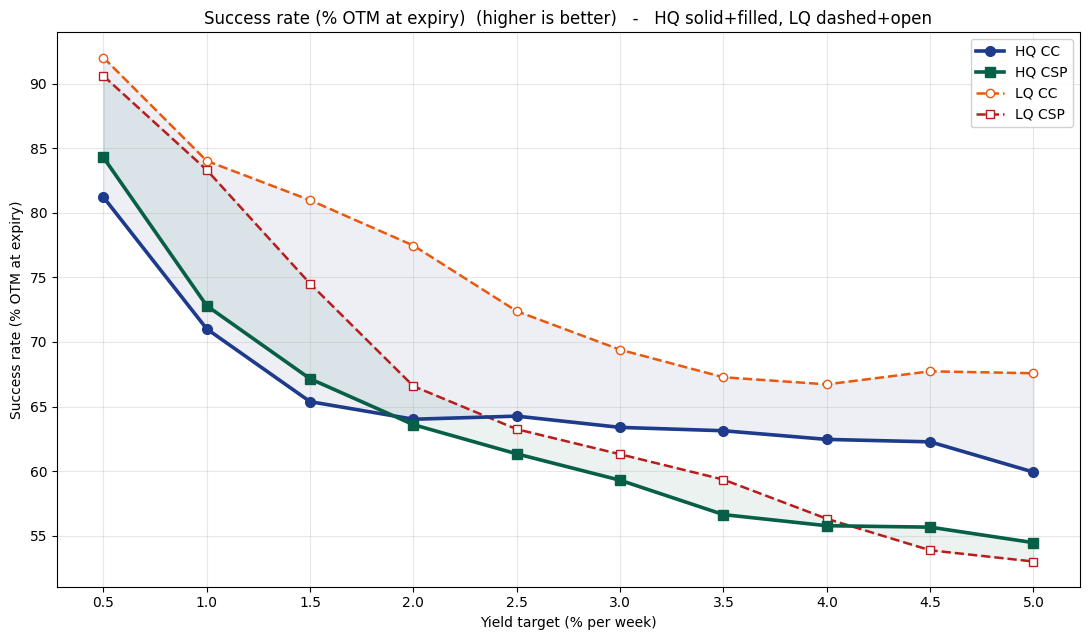

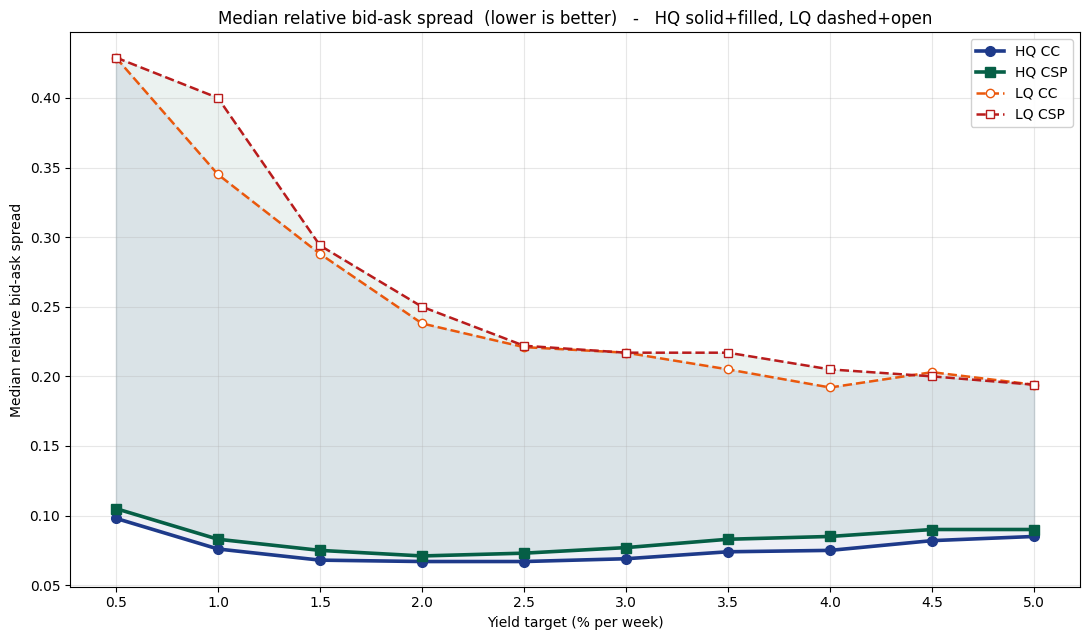

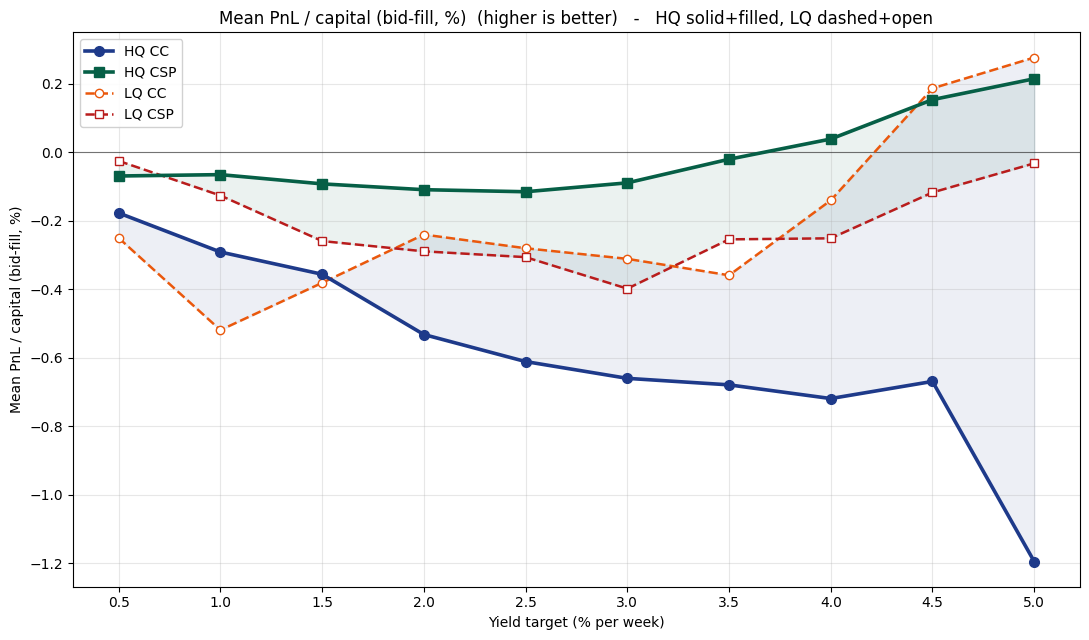

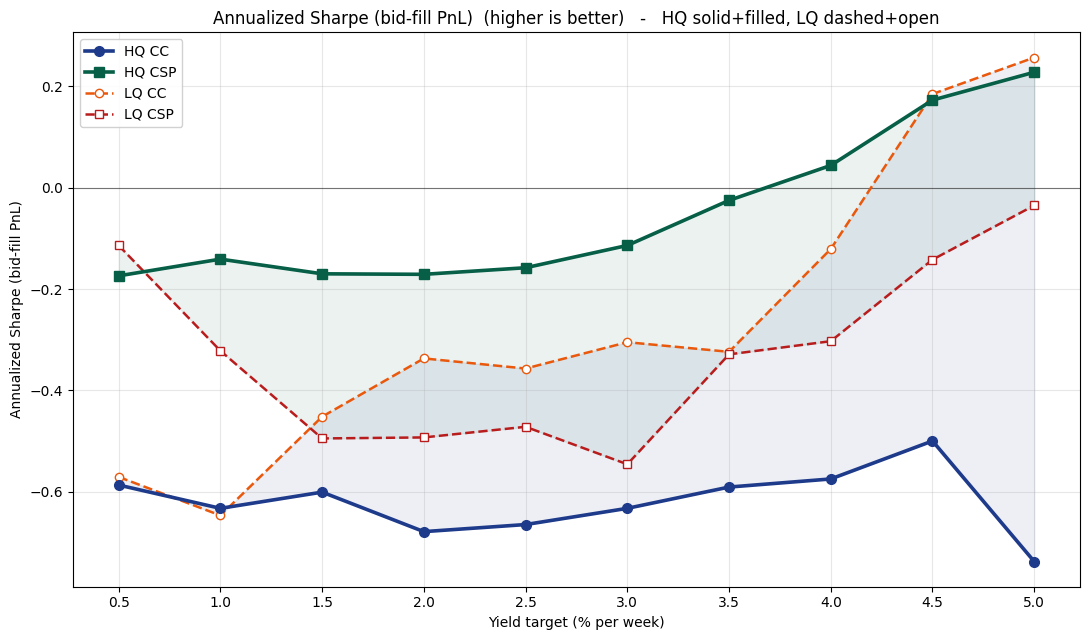

In [6]:
# Plot each metric as its own figure so they read large and can be inspected one at a time.
series_styles = {
    ("HQ", "CC"):  {"color": "#1e3a8a", "linestyle": "-",  "linewidth": 2.6, "marker": "o", "markersize": 7, "markerfacecolor": "#1e3a8a", "zorder": 4, "label": "HQ CC"},
    ("HQ", "CSP"): {"color": "#065f46", "linestyle": "-",  "linewidth": 2.6, "marker": "s", "markersize": 7, "markerfacecolor": "#065f46", "zorder": 4, "label": "HQ CSP"},
    ("LQ", "CC"):  {"color": "#ea580c", "linestyle": "--", "linewidth": 1.8, "marker": "o", "markersize": 6, "markerfacecolor": "white",   "zorder": 3, "label": "LQ CC"},
    ("LQ", "CSP"): {"color": "#b91c1c", "linestyle": "--", "linewidth": 1.8, "marker": "s", "markersize": 6, "markerfacecolor": "white",   "zorder": 3, "label": "LQ CSP"},
}
fill_colors = {"CC": "#1e3a8a", "CSP": "#065f46"}

metrics = [
    ("pct_OTM_at_exp",    "Success rate (% OTM at expiry)",   "success_rate", "higher is better"),
    ("median_spread_rel", "Median relative bid-ask spread",   "spread",       "lower is better"),
    ("mean_pnl_bid_pct",  "Mean PnL / capital (bid-fill, %)", "pnl_bid",      "higher is better"),
    ("sharpe_annual",     "Annualized Sharpe (bid-fill PnL)", "sharpe_annual","higher is better"),
]

out_dir = Path("output/04_compare_high_vs_low_quality_ticker")
out_dir.mkdir(parents=True, exist_ok=True)

for col, title, slug, direction in metrics:
    fig, ax = plt.subplots(figsize=(11, 6.5))
    # Shade the gap between HQ and LQ of the same type to visualize the filter's effect.
    for type_ in TYPES:
        hq_sub = full_summary[(full_summary["tier"] == "HQ") & (full_summary["type"] == type_)].sort_values("yield_target")
        lq_sub = full_summary[(full_summary["tier"] == "LQ") & (full_summary["type"] == type_)].sort_values("yield_target")
        if hq_sub.empty or lq_sub.empty:
            continue
        ax.fill_between(
            hq_sub["yield_target"].values * 100,
            hq_sub[col].values,
            lq_sub[col].values,
            color=fill_colors[type_],
            alpha=0.08,
            zorder=1,
        )
    for key, style in series_styles.items():
        tier, type_ = key
        sub = full_summary[(full_summary["tier"] == tier) & (full_summary["type"] == type_)].sort_values("yield_target")
        if sub.empty:
            continue
        ax.plot(sub["yield_target"] * 100, sub[col], **style)
    ax.set_xlabel("Yield target (% per week)")
    ax.set_ylabel(title)
    ax.set_title(f"{title}  ({direction})   -   HQ solid+filled, LQ dashed+open")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10, loc="best", framealpha=0.9)
    ax.set_xticks([y * 100 for y in YIELD_TARGETS])
    if col in ("mean_pnl_bid_pct", "sharpe_annual"):
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    fig.tight_layout()
    fig.savefig(out_dir / f"hq_vs_lq_{slug}.png", dpi=120)
    plt.show()
    plt.close(fig)

## Per-ticker breakdown (CC and CSP across yield targets)

Each bar is one ticker's mean weekly P&L on bid-fill at the given (type, yield target) bucket. Green = HQ, red = LQ. Sorted ascending. `n=X` annotation is the number of sampled weeks contributing to that ticker's mean.

Watch for:
- Red bars far to the right (LQ tickers that would have survived - revisit thresholds?)
- Green bars far to the left (HQ tickers that underperform - candidate for a tighter filter?)
- LQ tickers with `n ≈ 0` - filter caught them structurally; no trades were even attempted.
- How the distribution shifts as yield target rises: low targets pick near-ATM strikes, high targets pick further-OTM strikes, so tails stretch accordingly.

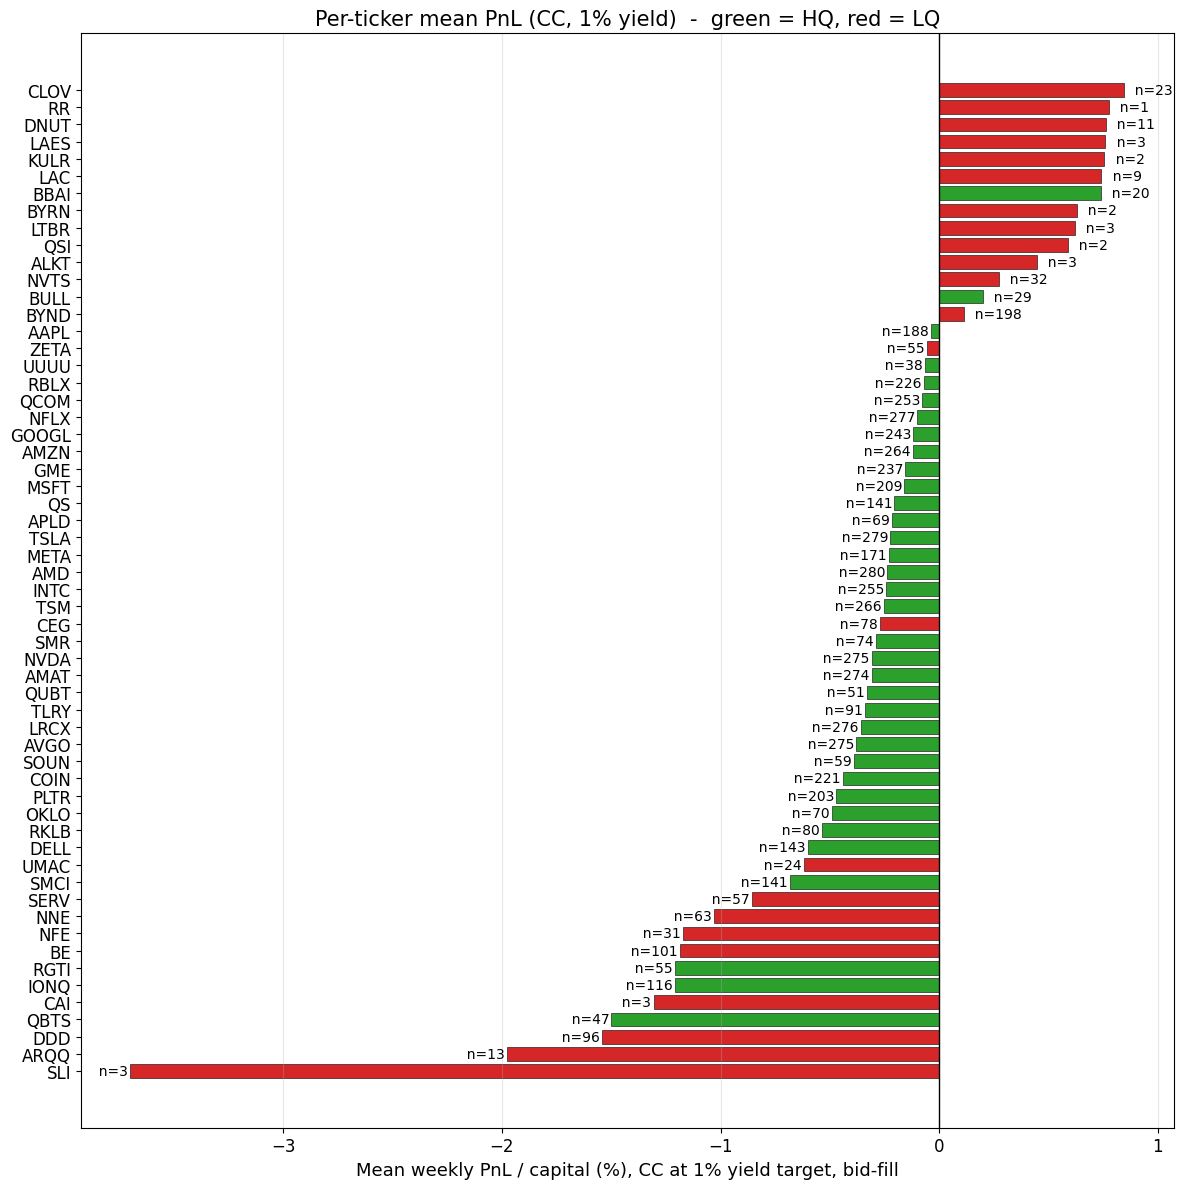

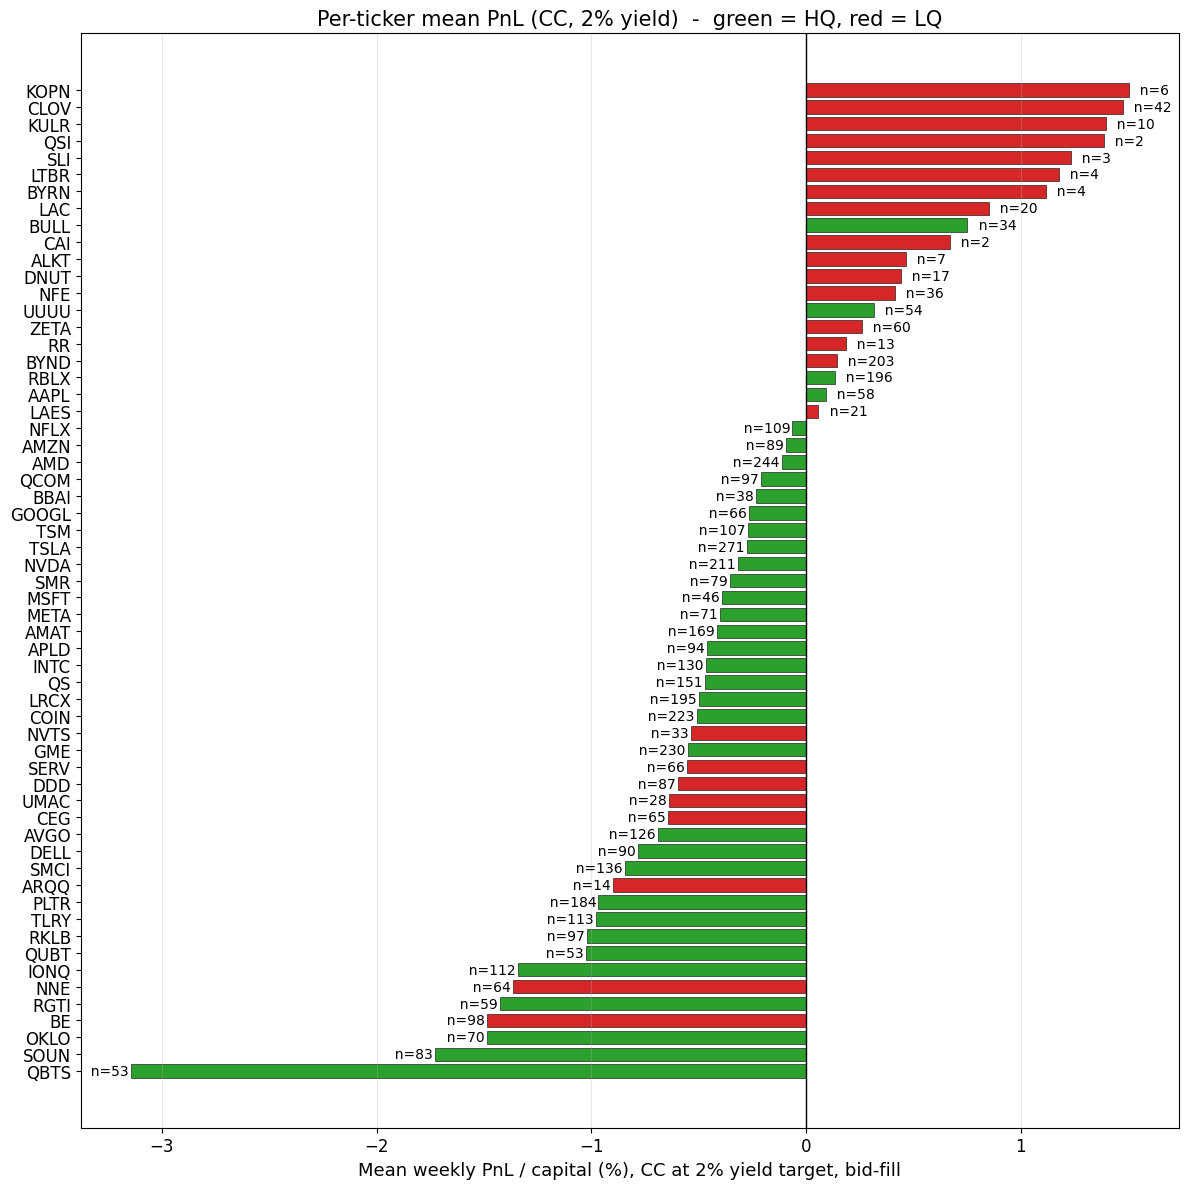

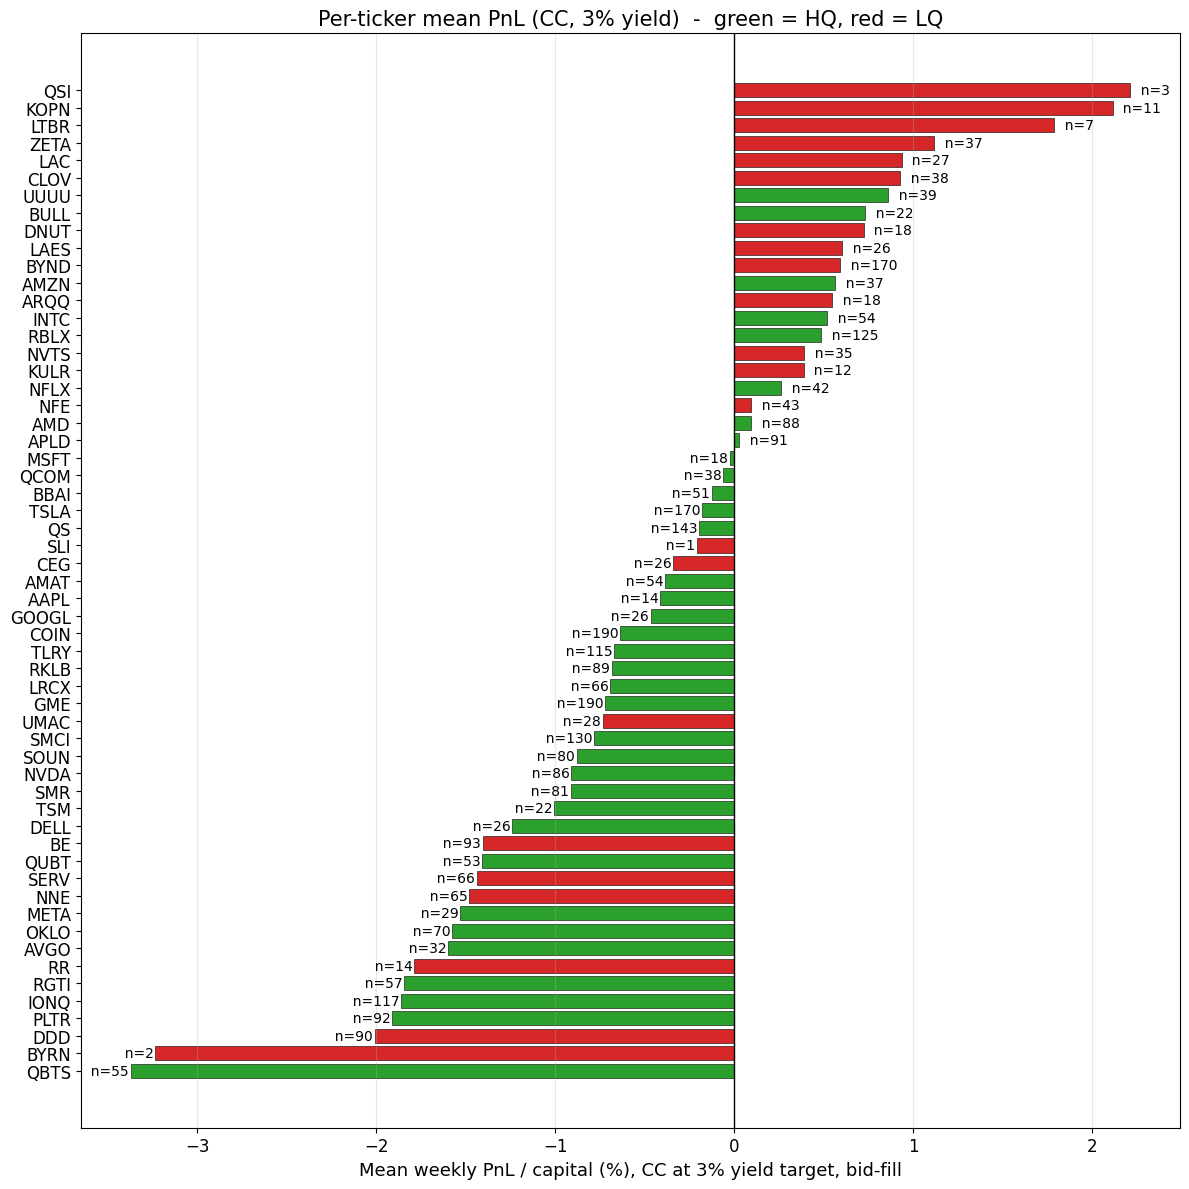

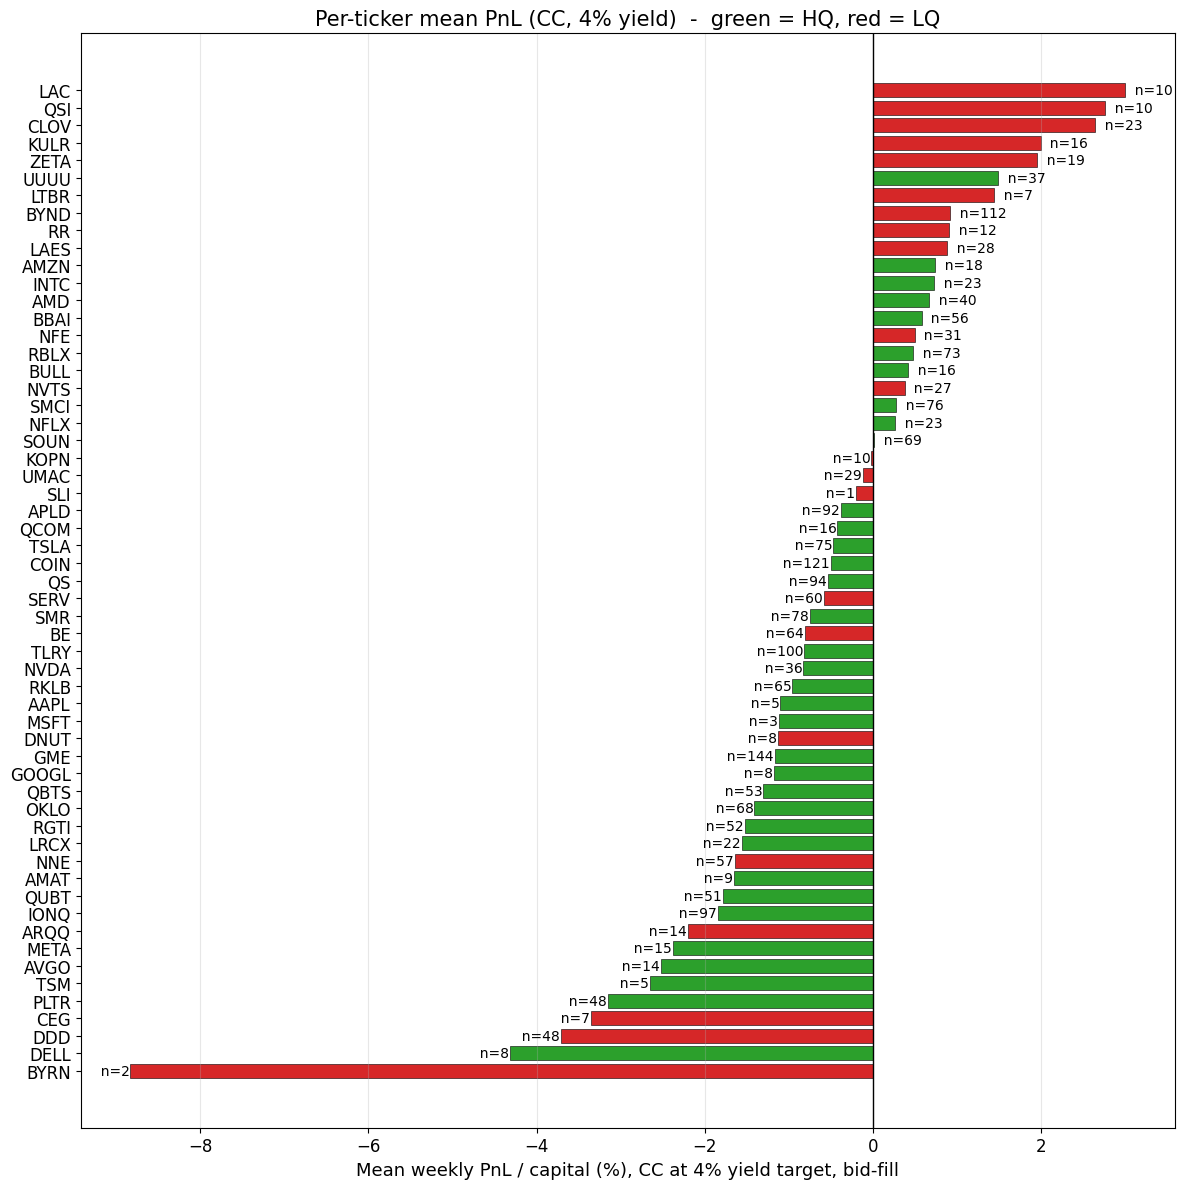

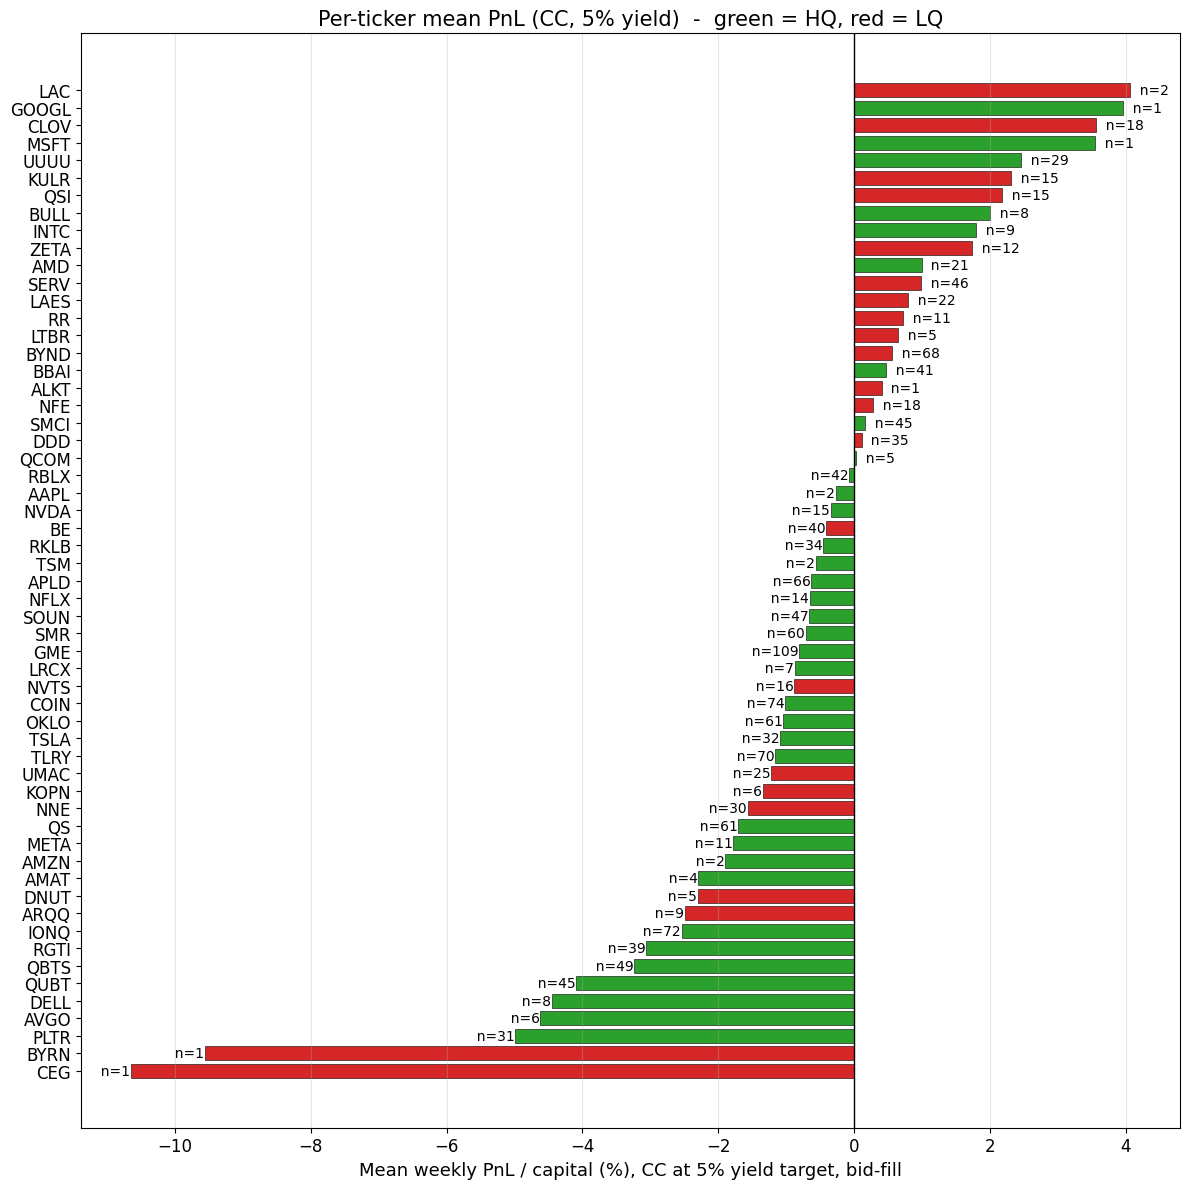

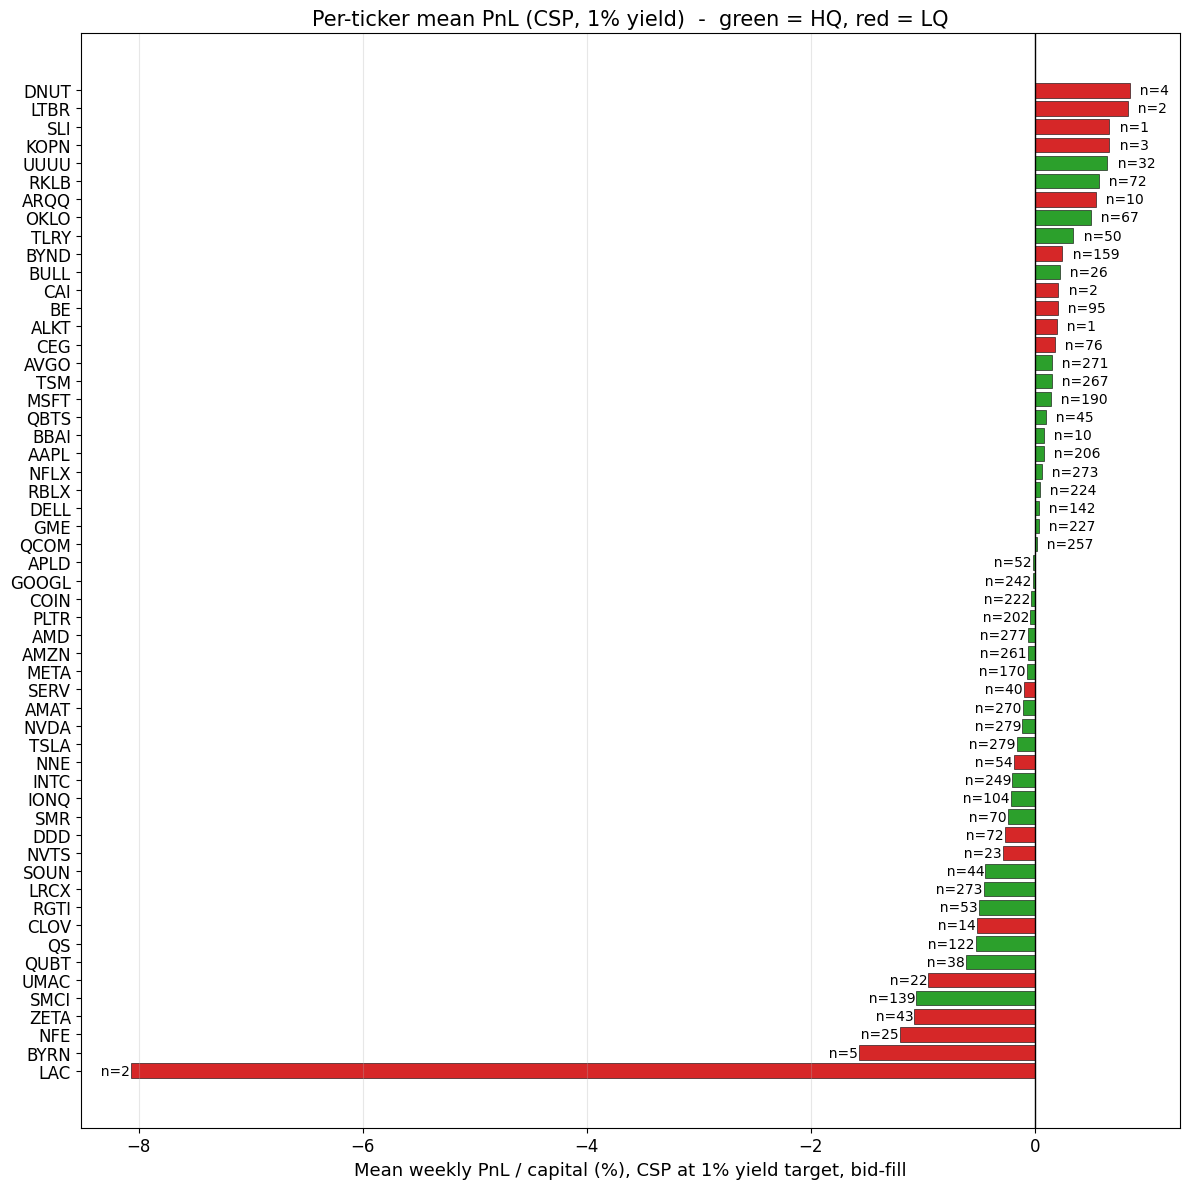

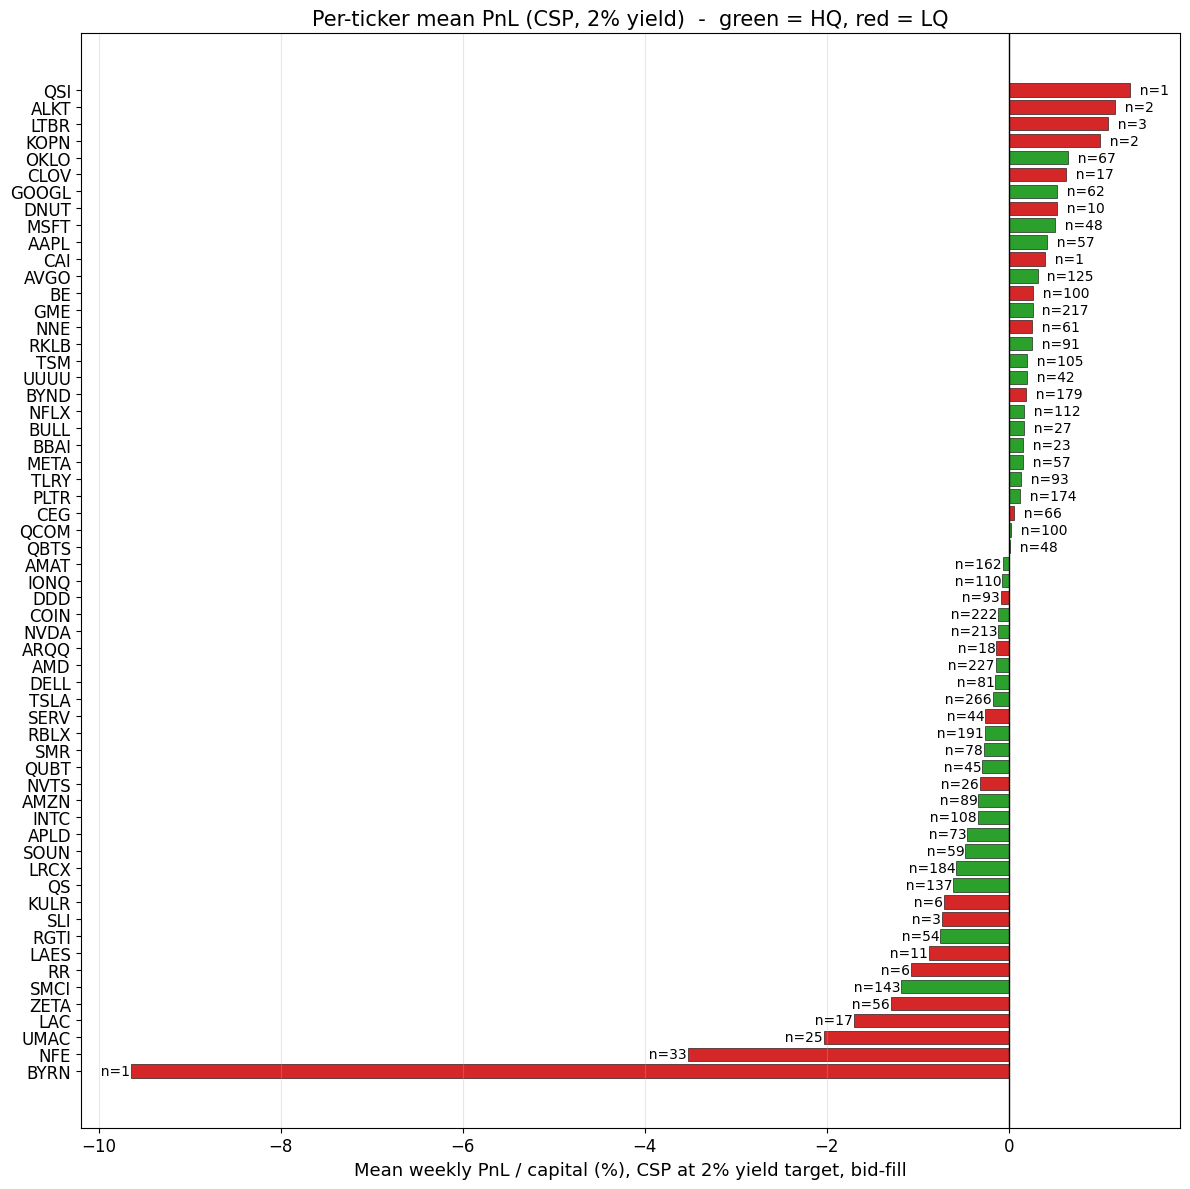

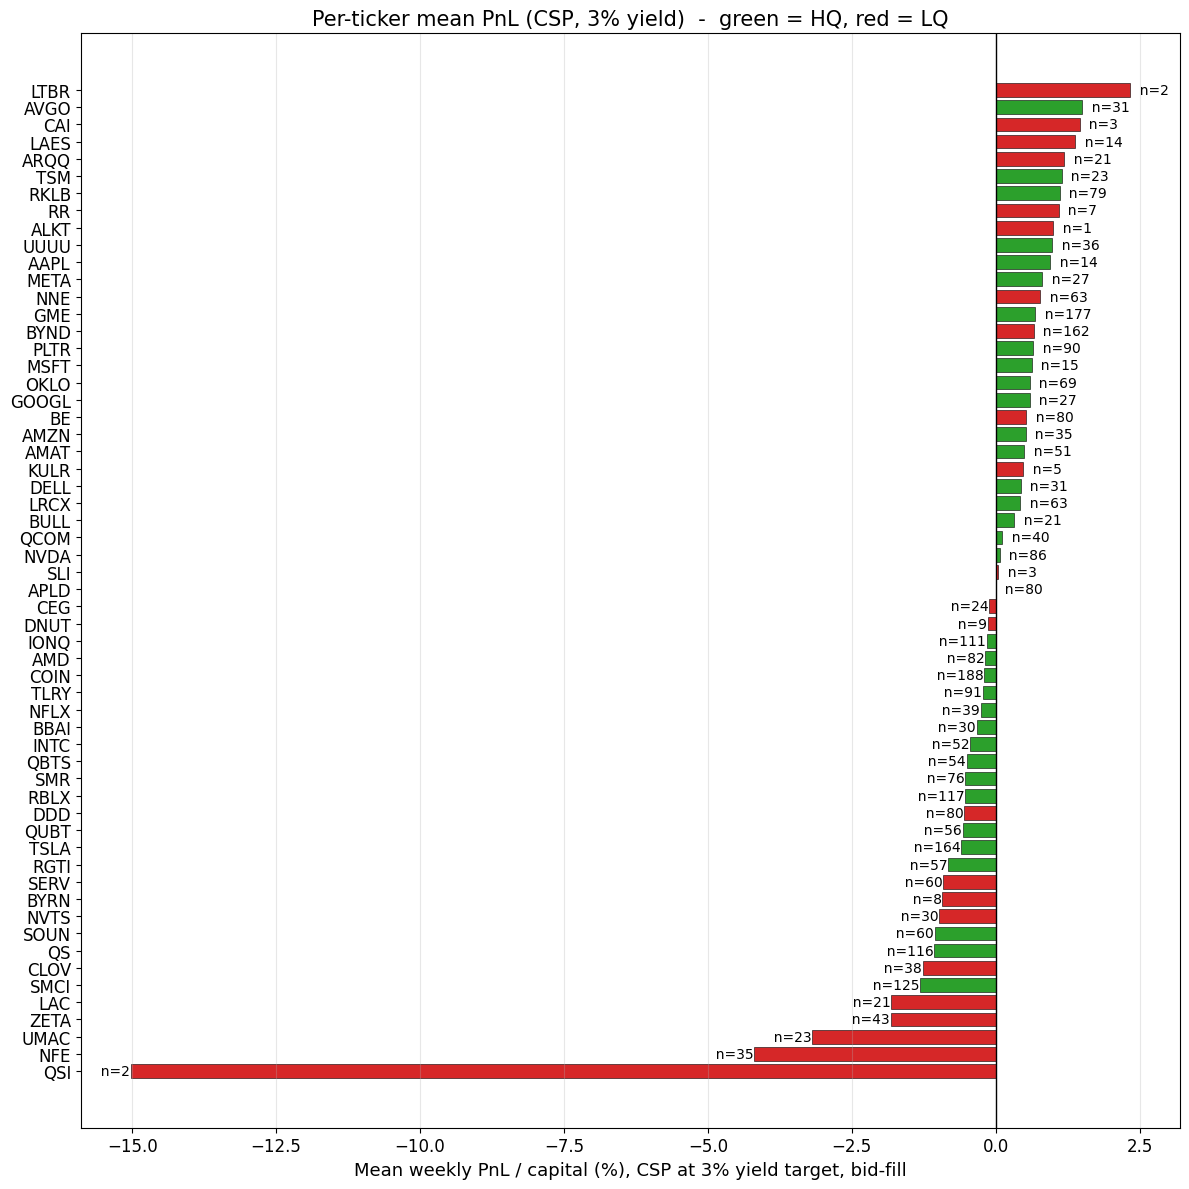

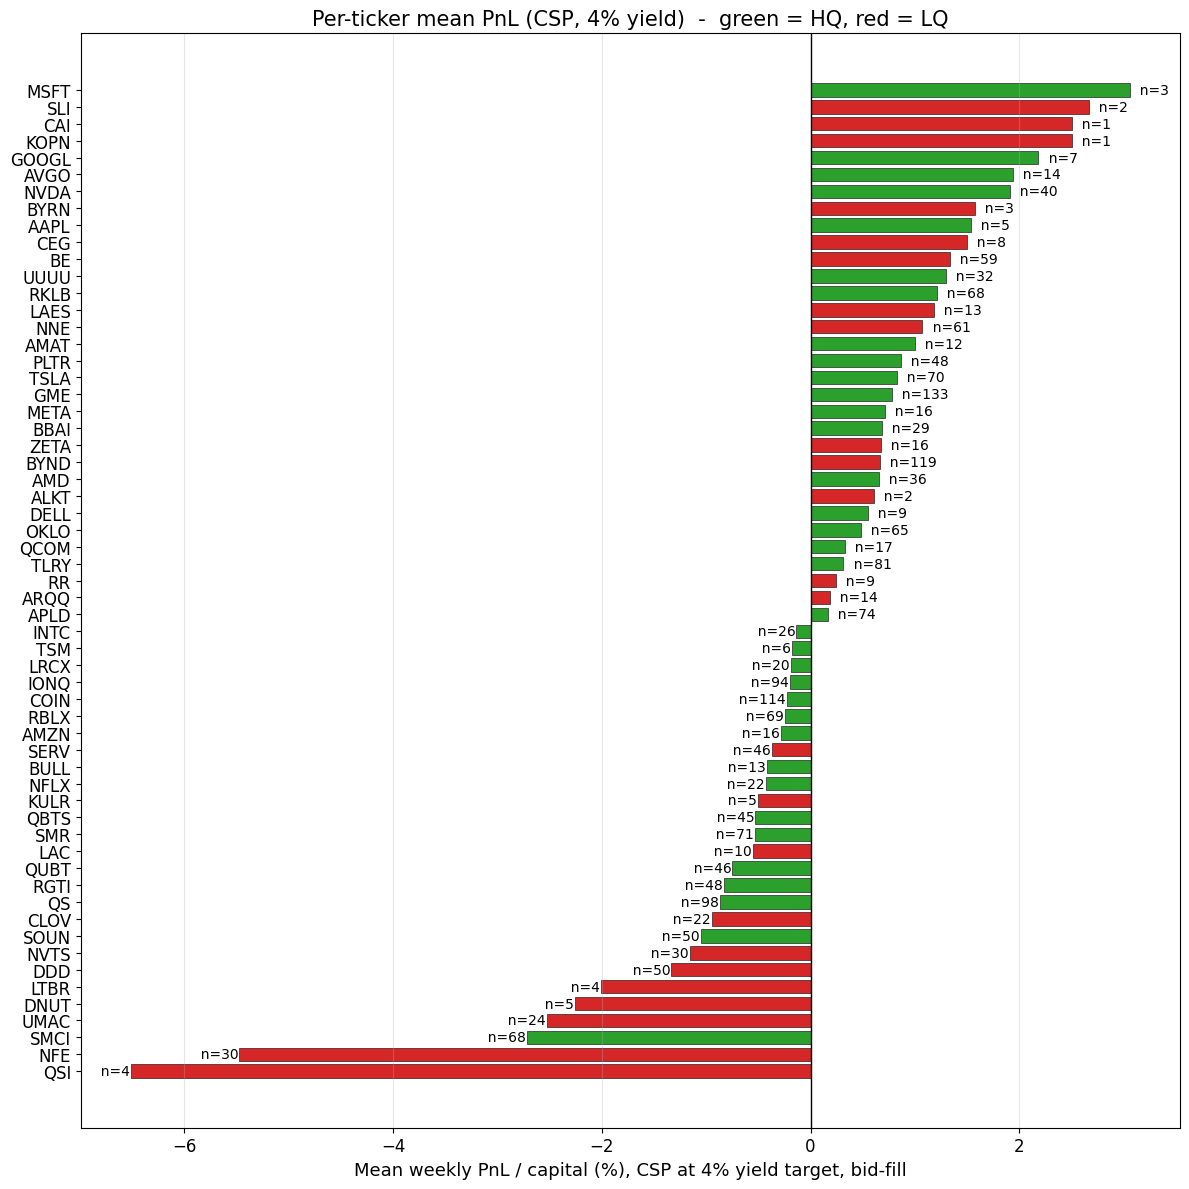

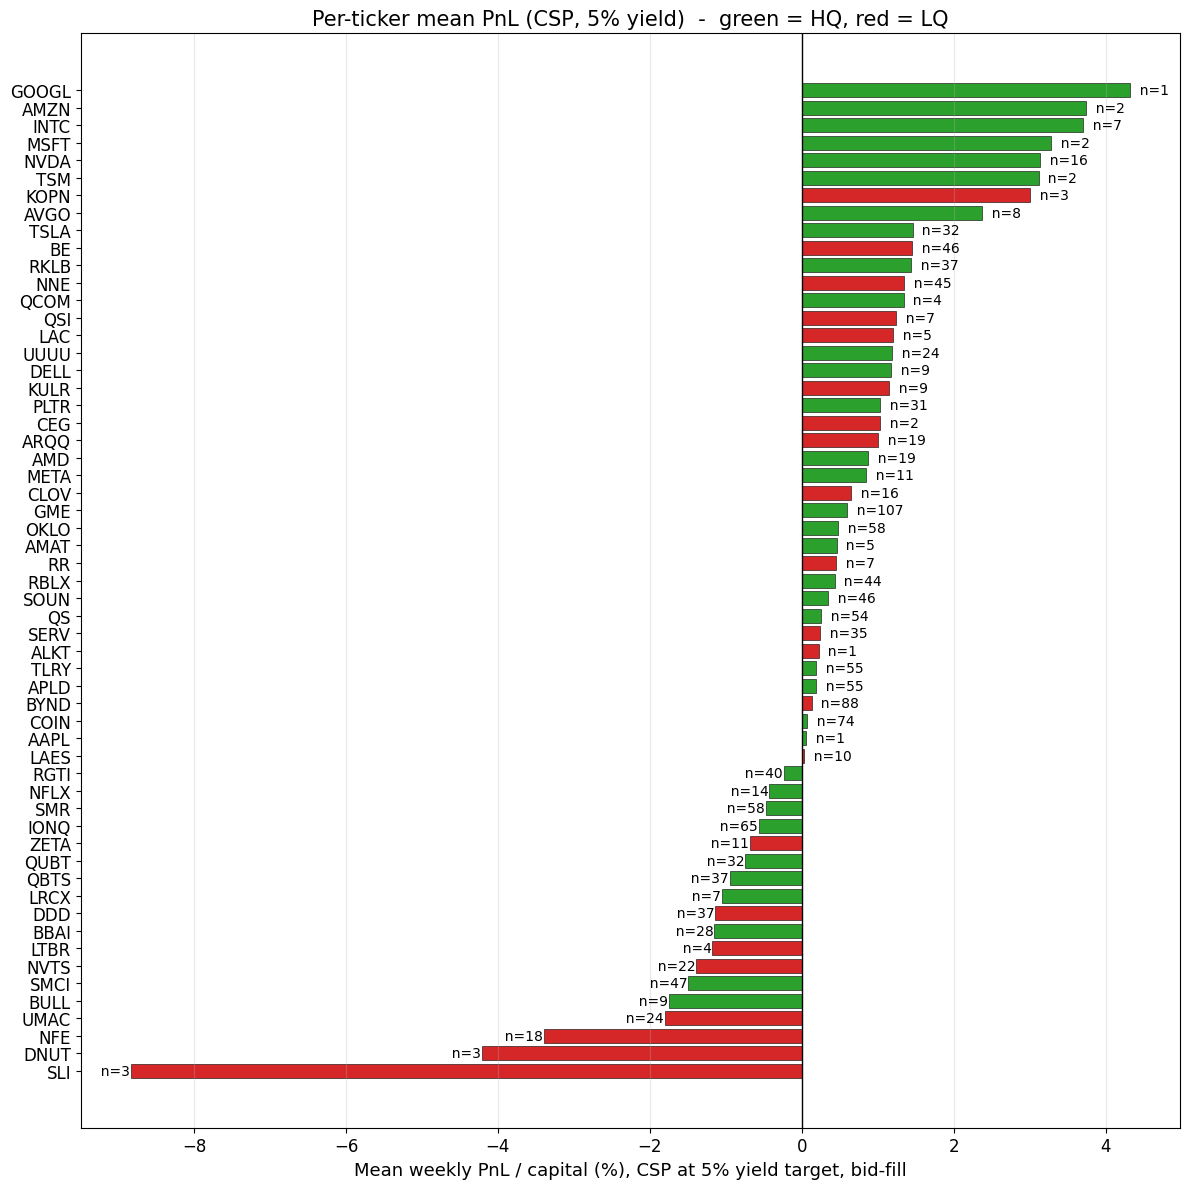

In [7]:
def plot_per_ticker(type_key, yield_target):
    slice_ = both[(both["type"] == type_key) & (both["yield_target"] == yield_target)]
    per_ticker = (
        slice_.groupby(["tier", "ticker"])["pnl_pct_capital"]
        .agg(["mean", "count"])
        .reset_index()
    )
    per_ticker = per_ticker.sort_values("mean")
    per_ticker["mean_pct"] = 100 * per_ticker["mean"]

    fig, ax = plt.subplots(figsize=(12, 12))
    colors = per_ticker["tier"].map({"HQ": "tab:green", "LQ": "tab:red"})
    ax.barh(
        per_ticker["ticker"],
        per_ticker["mean_pct"],
        color=colors,
        edgecolor="black",
        linewidth=0.4,
    )
    ax.axvline(0, color="black", linewidth=1)
    yield_pct = int(round(yield_target * 100))
    ax.set_xlabel(
        f"Mean weekly PnL / capital (%), {type_key} at {yield_pct}% yield target, bid-fill",
        fontsize=13,
    )
    ax.set_title(
        f"Per-ticker mean PnL ({type_key}, {yield_pct}% yield)  -  green = HQ, red = LQ",
        fontsize=15,
    )
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(alpha=0.3, axis="x")
    for i, row in enumerate(per_ticker.itertuples()):
        ax.text(
            row.mean_pct + 0.01 if row.mean_pct >= 0 else row.mean_pct - 0.01,
            i,
            f"  n={row.count}",
            va="center",
            ha="left" if row.mean_pct >= 0 else "right",
            fontsize=10,
            color="black",
        )
    fig.tight_layout()
    fname = f"per_ticker_{type_key.lower()}_{yield_pct}pct.png"
    fig.savefig(Path("output/04_compare_high_vs_low_quality_ticker") / fname, dpi=120)
    plt.show()
    plt.close(fig)


for type_key in ["CC", "CSP"]:
    for yt in [0.01, 0.02, 0.03, 0.04, 0.05]:
        plot_per_ticker(type_key, yt)